# Employee Salary Data Analysis & Salary Prediction

## End-to-End Data Analytics Capstone Project

### Internship Project - Syntecxhub

**Prepared by:** Alisha Mansoori

**Tools Used:** Python, Pandas, NumPy, Matplotlib, Scikit-learn

**Objective:**
Analyze employee salary data, perform data cleaning, exploratory data analysis (EDA), visualize insights, and build a machine learning model to predict salary categories.

 Import Libraries

In [42]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Load Dataset

In [43]:
columns = [
    "age","workclass","fnlwgt","education","education_num",
    "marital_status","occupation","relationship","race","sex",
    "capital_gain","capital_loss","hours_per_week",
    "native_country","salary"
]

df = pd.read_csv(
    "data/adult.csv",
    header=None,
    names=columns,
    skipinitialspace=True,
    na_values="?"
)

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,salary
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


 Dataset Information

In [44]:
df.shape

(32561, 15)

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  31978 non-null  object
 14  salary          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [46]:
df.describe(include="all")

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,salary
count,32561.000000,30725,3.256100e+04,32561,32561.000000,32561,30718,32561,32561,32561,32561.000000,32561.000000,32561.000000,31978,32561
unique,NaN,8,NaN,16,NaN,7,14,6,5,2,NaN,NaN,NaN,41,2
top,NaN,Private,NaN,HS-grad,NaN,Married-civ-spouse,Prof-specialty,Husband,White,Male,NaN,NaN,NaN,United-States,<=50K
freq,NaN,22696,NaN,10501,NaN,14976,4140,13193,27816,21790,NaN,NaN,NaN,29170,24720
mean,38.581647,NaN,1.897784e+05,NaN,10.080679,NaN,NaN,NaN,NaN,NaN,1077.648844,87.303830,40.437456,NaN,NaN
std,13.640433,NaN,1.055500e+05,NaN,2.572720,NaN,NaN,NaN,NaN,NaN,7385.292085,402.960219,12.347429,NaN,NaN
min,17.000000,NaN,1.228500e+04,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN,NaN
25%,28.000000,NaN,1.178270e+05,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
50%,37.000000,NaN,1.783560e+05,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
75%,48.000000,NaN,2.370510e+05,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,45.000000,NaN,NaN


Data Cleaning

In [47]:
df.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
salary               0
dtype: int64

In [48]:
df.dropna(inplace=True)

In [49]:
df.drop_duplicates(inplace=True)

In [50]:
df.shape

(30139, 15)

Exploratory Data Analysis (EDA)

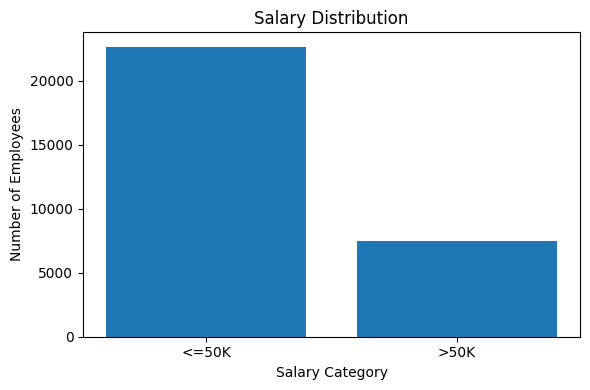

In [55]:
salary_counts = df['salary'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(salary_counts.index, salary_counts.values)
plt.title("Salary Distribution")
plt.xlabel("Salary Category")
plt.ylabel("Number of Employees")
plt.tight_layout()
plt.savefig("images/salary_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
plt.show()

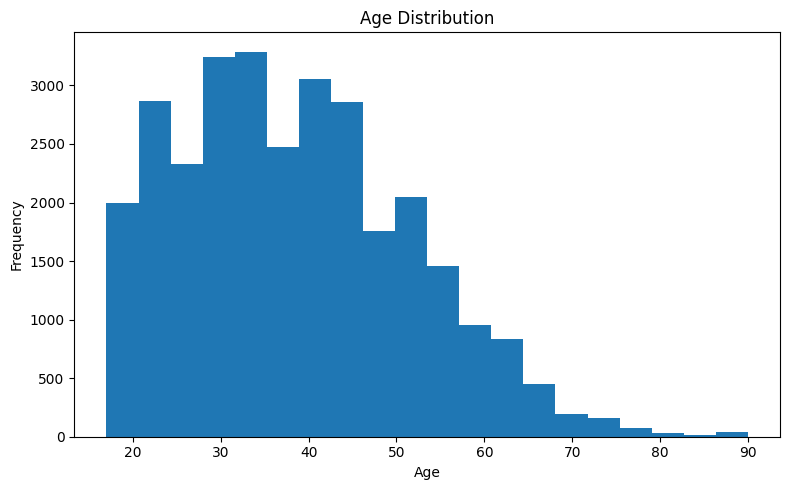

In [54]:
plt.figure(figsize=(8,5))
plt.hist(df['age'], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("images/age_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
plt.show()

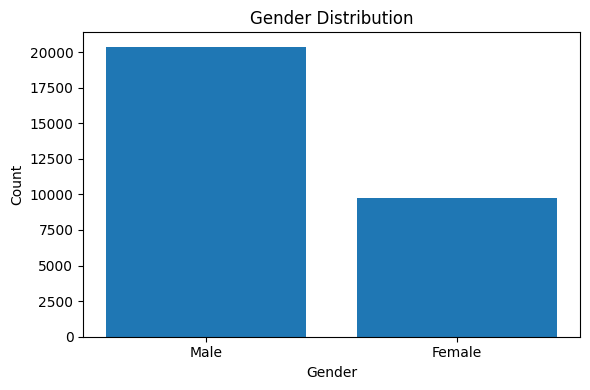

In [57]:
gender = df['sex'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(gender.index, gender.values)
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("images/gender_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


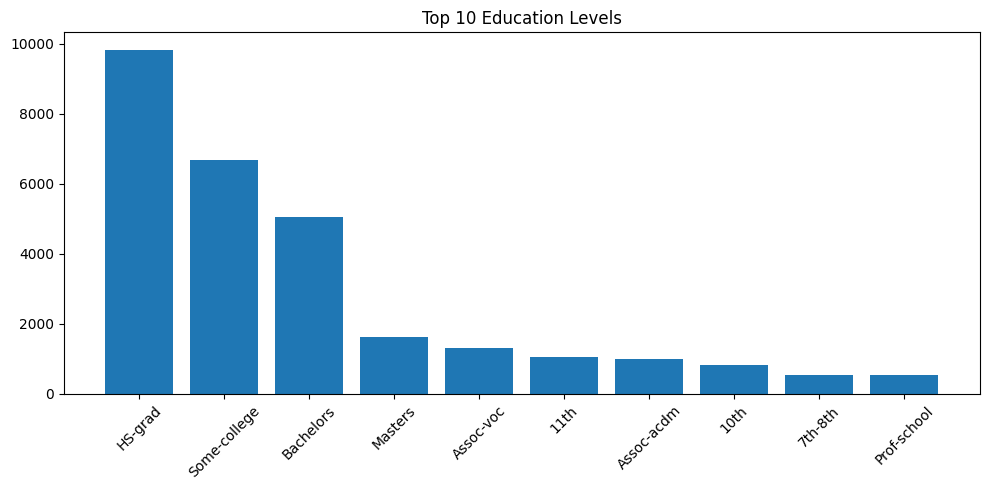

In [70]:
education = df['education'].value_counts().head(10)

plt.figure(figsize=(10,5))
plt.bar(education.index, education.values)
plt.title("Top 10 Education Levels")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("images/top_10_education_levels.png", dpi=300, bbox_inches="tight")
plt.show()

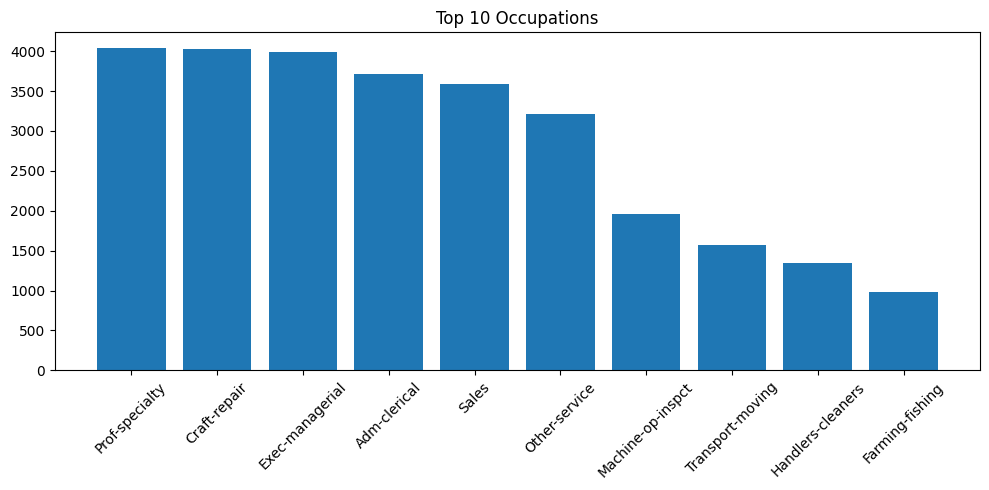

In [69]:
occupation = df['occupation'].value_counts().head(10)

plt.figure(figsize=(10,5))
plt.bar(occupation.index, occupation.values)
plt.title("Top 10 Occupations")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("images/top_10_occupations.png", dpi=300, bbox_inches="tight")
plt.show()

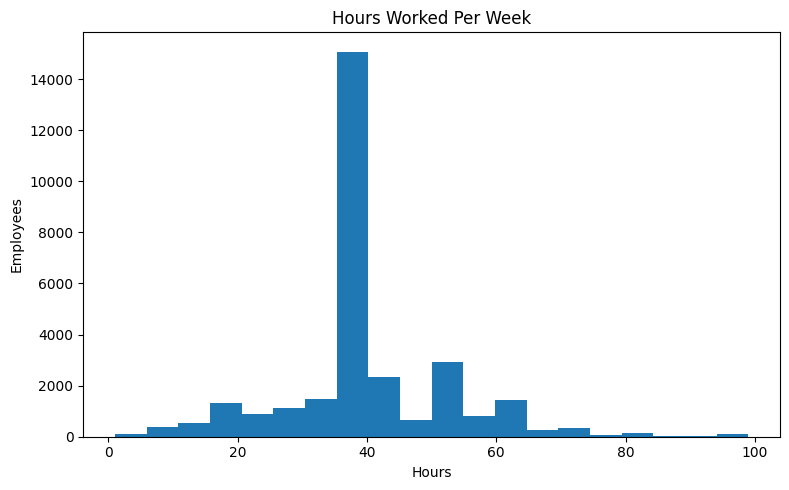

In [66]:
plt.figure(figsize=(8,5))
plt.hist(df['hours_per_week'], bins=20)
plt.title("Hours Worked Per Week")
plt.xlabel("Hours")
plt.ylabel("Employees")
plt.tight_layout()
plt.savefig("images/hours_worked_per_week.png", dpi=300, bbox_inches="tight")
plt.show()

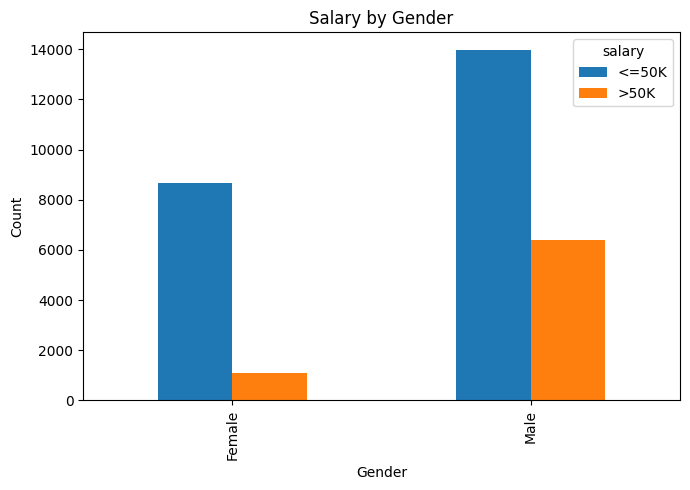

In [65]:
salary_gender = pd.crosstab(df['sex'], df['salary'])

salary_gender.plot(kind='bar', figsize=(7,5))
plt.title("Salary by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("images/salary_by_gender.png", dpi=300, bbox_inches="tight")
plt.show()

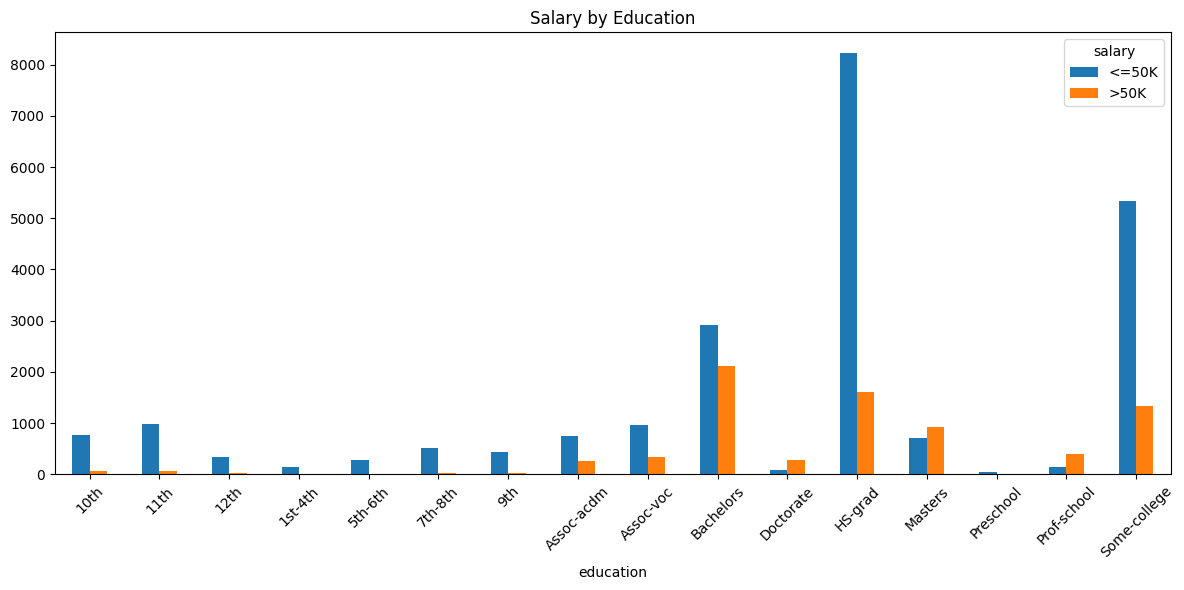

In [67]:
salary_education = pd.crosstab(df['education'], df['salary'])

salary_education.plot(kind='bar', figsize=(12,6))
plt.title("Salary by Education")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("images/salary_by_education.png", dpi=300, bbox_inches="tight")
plt.show()

In [56]:
df_encoded = df.copy()

encoder = LabelEncoder()

for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = encoder.fit_transform(df_encoded[col])

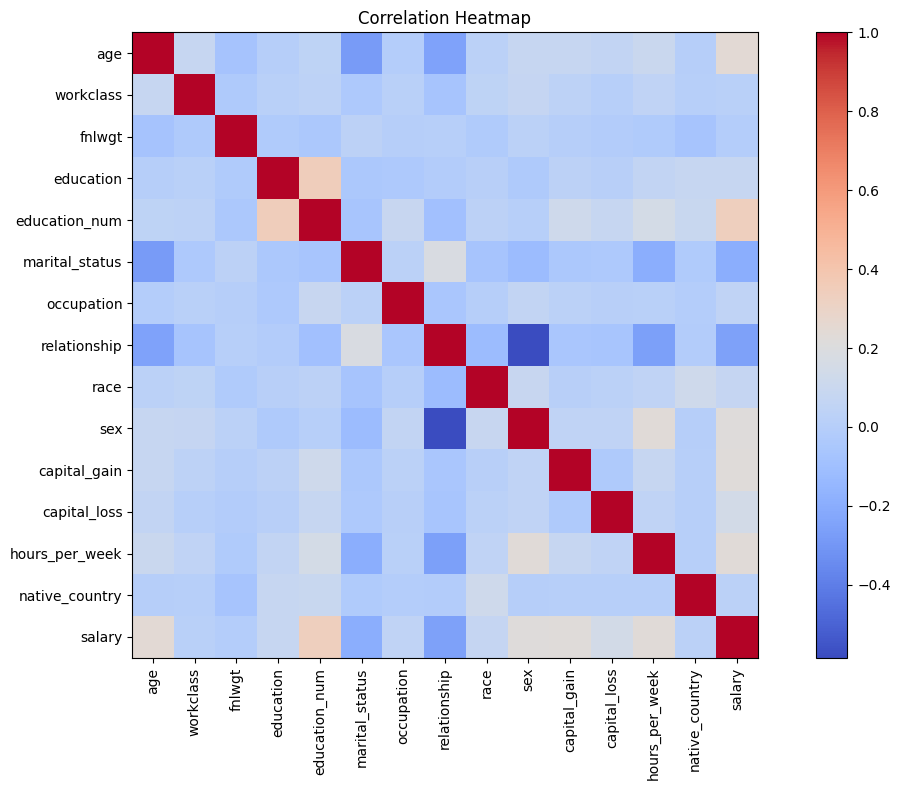

In [68]:
plt.figure(figsize=(12,8))

plt.imshow(df_encoded.corr(), cmap='coolwarm')
plt.colorbar()

plt.xticks(range(len(df_encoded.columns)), df_encoded.columns, rotation=90)
plt.yticks(range(len(df_encoded.columns)), df_encoded.columns)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("images/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

## Key Insights

1. Most employees earn <=50K.
2. The majority of employees are aged between 30 and 50 years.
3. Private workclass has the highest number of employees.
4. Higher education is associated with higher salaries.
5. Employees working more than 40 hours per week are more likely to earn >50K.

Machine Learning

In [71]:
from sklearn.preprocessing import LabelEncoder

df_ml = df.copy()

encoder = LabelEncoder()

for col in df_ml.columns:
    if df_ml[col].dtype == "object":
        df_ml[col] = encoder.fit_transform(df_ml[col])

df_ml.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,salary
0,39,5,77516,9,13,4,0,1,4,1,2174,0,40,38,0
1,50,4,83311,9,13,2,3,0,4,1,0,0,13,38,0
2,38,2,215646,11,9,0,5,1,4,1,0,0,40,38,0
3,53,2,234721,1,7,2,5,0,2,1,0,0,40,38,0
4,28,2,338409,9,13,2,9,5,2,0,0,0,40,4,0


In [80]:
df.to_csv("outputs/cleaned_dataset.csv", index=False)

print("Cleaned dataset saved!")

Cleaned dataset saved!


In [72]:
X = df_ml.drop("salary", axis=1)
y = df_ml["salary"]

In [73]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [74]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [81]:
predictions = X_test.copy()
predictions["Actual"] = y_test.values
predictions["Predicted"] = y_pred

predictions.to_csv("outputs/predictions.csv", index=False)

print("Predictions saved!")

Predictions saved!


In [75]:
y_pred = model.predict(X_test)

In [76]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy*100:.2f}%")

Model Accuracy: 85.65%


In [83]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))
with open("outputs/classification_report.txt", "w") as f:
    f.write(report)

print(report)

              precision    recall  f1-score   support

           0       0.88      0.93      0.91      4485
           1       0.76      0.64      0.70      1543

    accuracy                           0.86      6028
   macro avg       0.82      0.79      0.80      6028
weighted avg       0.85      0.86      0.85      6028

              precision    recall  f1-score   support

           0       0.88      0.93      0.91      4485
           1       0.76      0.64      0.70      1543

    accuracy                           0.86      6028
   macro avg       0.82      0.79      0.80      6028
weighted avg       0.85      0.86      0.85      6028



In [84]:
accuracy = accuracy_score(y_test, y_pred)

with open("outputs/model_accuracy.txt", "w") as f:
    f.write(f"Model Accuracy: {accuracy*100:.2f}%")

print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 85.65%


<Figure size 600x600 with 0 Axes>

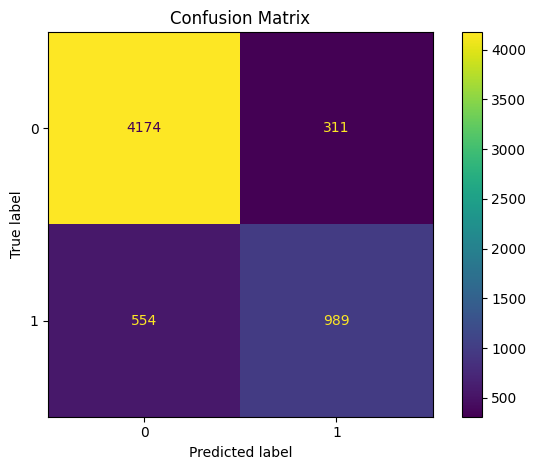

In [78]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

plt.title("Confusion Matrix")

plt.tight_layout()

plt.savefig("images/confusion_matrix.png", dpi=300)

plt.show()

Feature Importance

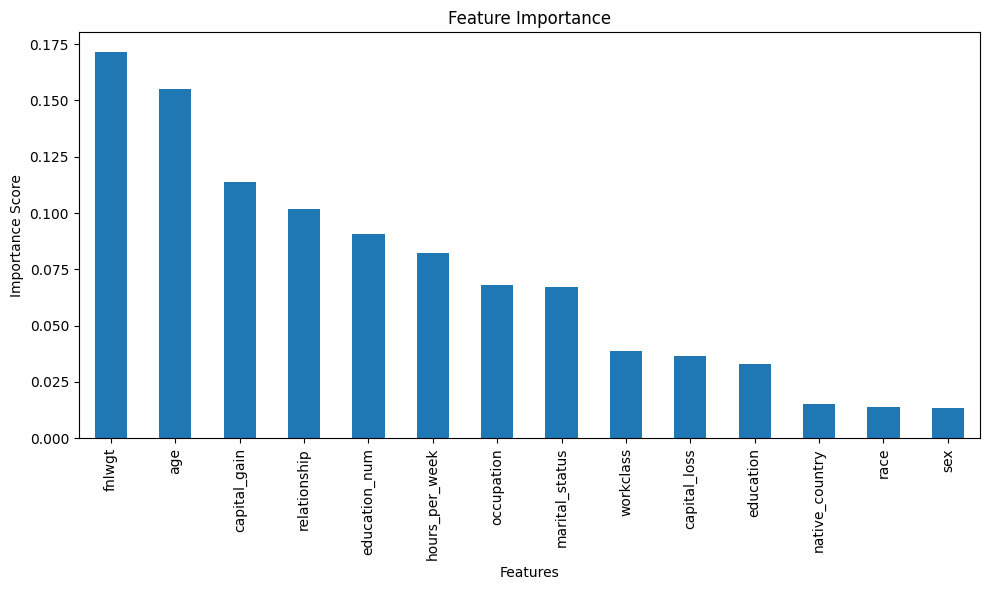

In [79]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feature_importance.plot(kind='bar')

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.tight_layout()
plt.savefig("images/feature_importance.png", dpi=300)

plt.show()

In [85]:
feature_df = feature_importance.reset_index()
feature_df.columns = ["Feature", "Importance"]

feature_df.to_csv("outputs/feature_importance.csv", index=False)

print("Feature importance saved!")

Feature importance saved!


# Model Evaluation

## Algorithm Used
- Random Forest Classifier

## Model Accuracy
- (Write the accuracy printed by your notebook, for example 85.2%)

## Evaluation Metrics
- Accuracy Score
- Classification Report
- Confusion Matrix

## Observation
The Random Forest model achieved good predictive performance and was able to classify employee salary categories effectively.

# Business Insights

1. Employees with higher education levels are more likely to earn more than 50K.

2. Employees working longer hours generally have higher salaries.

3. Capital gain is one of the strongest indicators of high income.

4. Age has a moderate positive relationship with salary.

5. Private sector employees form the largest group in the dataset.

6. Most employees belong to the <=50K salary category.

7. Education and occupation significantly influence salary prediction.

# Conclusion

This project analyzed employee salary data using Python.

The dataset was cleaned, explored through visualizations, and a Random Forest Classifier was trained to predict salary categories.

The project demonstrates the complete Data Analytics workflow including:

- Data Cleaning
- Exploratory Data Analysis
- Data Visualization
- Machine Learning
- Model Evaluation
- Business Insights

This project can help organizations understand salary trends and support data-driven decision-making.